<a href="https://colab.research.google.com/github/Chinh2702/KTLT_PYTHONG/blob/gh-pages/2_2_3_B%C3%A0i_t%E1%BA%ADp_th%E1%BB%B1c_h%C3%A0nh_1_X%C3%A2y_d%E1%BB%B1ng_m%C3%B4_h%C3%ACnh_t%E1%BB%AB_gi%E1%BA%A3i_thu%E1%BA%ADt_SVM_tr%C3%AAn_d%E1%BB%AF_li%E1%BB%87u_b%E1%BB%87nh_ti%E1%BB%83u_%C4%91%C6%B0%E1%BB%9Dng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Số dòng trùng lặp: 0
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-nul

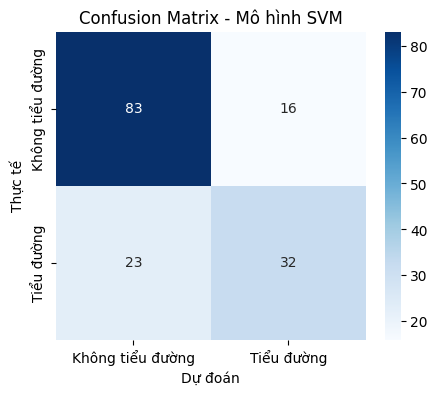

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

df.head()

duplicate_rows = df[df.duplicated()]
print(f"Số dòng trùng lặp: {duplicate_rows.shape[0]}")

df = df.drop_duplicates()

print(df.dtypes)

print(df.info())

cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[cols_with_zero] == 0).sum())

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

print(df.isnull().sum())

col = 'Glucose'
print(f"Mean {col}: ", np.nanmean(df[col]))
print(f"Median {col}: ", np.nanmedian(df[col]))

mode_result = stats.mode(df[col], nan_policy='omit')
if np.ndim(mode_result.mode) == 0:
    mode_value = mode_result.mode
else:
    mode_value = mode_result.mode
print(f"Mode {col}: ", mode_value)

desc = df.describe()
print(desc)

for col in cols_with_zero:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
print(df.isnull().sum())

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Không tiểu đường', 'Tiểu đường'], yticklabels=['Không tiểu đường', 'Tiểu đường'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Mô hình SVM')
plt.show()